# Fractional Brownian Bridge

## 1. Fractional Brownian Motion (fBm)

**Fractional Brownian Motion** $B_H(t)$ is a continuous centered Gaussian process with covariance:

$$\mathrm{Cov}\bigl(B_H(t), B_H(s)\bigr) = \frac{1}{2}\Bigl(t^{2H} + s^{2H} - |t-s|^{2H}\Bigr)$$

where $H \in (0,1)$ is the **Hurst exponent**:

- $H = 0.5$: Standard Brownian motion (independent increments)
- $H > 0.5$: Persistent / long-range dependent (smooth paths)
- $H < 0.5$: Anti-persistent (rough paths)

## 2. What is a Bridge?

A **bridge** is a stochastic process conditioned to return to a fixed value at a terminal time. For a process $X(t)$ on $[0,T]$ with $X(0)=0$, a bridge satisfies $X(T)=0$.

For **standard Brownian motion** ($H=0.5$), the bridge is:

$$B^0(t) = B(t) - \frac{t}{T} B(T)$$

## 3. Two Types of Fractional Brownian Bridges

For $H \neq 0.5$, fBm is **not Markovian**, so there are two natural bridge constructions:

### A. Linear (Tied-Down) Bridge
The simplest construction — subtract a linear trend:

$$\boxed{X_{\mathrm{lin}}(t) = B_H(t) - \frac{t}{T}\, B_H(T)}$$

This pins the endpoints to zero but does **not** preserve the conditional covariance structure of fBm.

### B. Gaussian Conditional Bridge
The statistically "correct" bridge uses Gaussian conditioning. For a Gaussian vector, conditioning on $B_H(T)=0$ gives:

$$\boxed{X_{\mathrm{cond}}(t) = B_H(t) - \frac{\mathrm{Cov}(B_H(t), B_H(T))}{\mathrm{Var}(B_H(T))}\, B_H(T)}$$

where:
$$\mathrm{Cov}(B_H(t), B_H(T)) = \frac{1}{2}\bigl(t^{2H} + T^{2H} - |T-t|^{2H}\bigr), \quad \mathrm{Var}(B_H(T)) = T^{2H}$$

**Key insight:** These two bridges are identical **only when $H=0.5$**. For $H \neq 0.5$, the conditional bridge has a different covariance structure.

## 4. Covariance of the Bridges

For the **conditional bridge**, the covariance is:
$$\mathrm{Cov}(X_{\mathrm{cond}}(t), X_{\mathrm{cond}}(s)) = C(t,s) - \frac{C(t,T)\,C(s,T)}{C(T,T)}$$

For the **linear bridge**:
$$\mathrm{Cov}(X_{\mathrm{lin}}(t), X_{\mathrm{lin}}(s)) = C(t,s) - \frac{t}{T}C(s,T) - \frac{s}{T}C(t,T) + \frac{ts}{T^2}C(T,T)$$


In [8]:
# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
import os

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Create local output directory
SAVE_DIR = './fbb_output'
os.makedirs(SAVE_DIR, exist_ok=True)


## 5. Simulation via Cholesky Decomposition

We generate fBm by computing its covariance matrix $C_{ij} = \mathrm{Cov}(B_H(t_i), B_H(t_j))$ and applying Cholesky decomposition: $C = LL^\top$, then $B_H = L \cdot Z$ where $Z \sim \mathcal{N}(0,I)$.


In [11]:
# Cell 2: Core Functions (unchanged)

def fbm_covariance(t, H):
    t = np.asarray(t)
    s = t[:, np.newaxis]
    t_row = t[np.newaxis, :]
    return 0.5 * (s**(2*H) + t_row**(2*H) - np.abs(s - t_row)**(2*H))


def generate_fbm(t, H):
    n = len(t)
    C = fbm_covariance(t, H)
    L = cholesky(C + 1e-12 * np.eye(n), lower=True)
    z = np.random.randn(n)
    return L @ z


def linear_bridge(t, H):
    X = generate_fbm(t, H)
    T = t[-1]
    return X - (t / T) * X[-1]


def conditional_bridge(t, H):
    X = generate_fbm(t, H)
    T = t[-1]
    C_tT = 0.5 * (t**(2*H) + T**(2*H) - np.abs(T - t)**(2*H))
    C_TT = T**(2*H)
    return X - (C_tT / C_TT) * X[-1]


## 6. Visualization: Sample Paths

Let's generate sample paths for different Hurst exponents and compare the two bridge constructions.


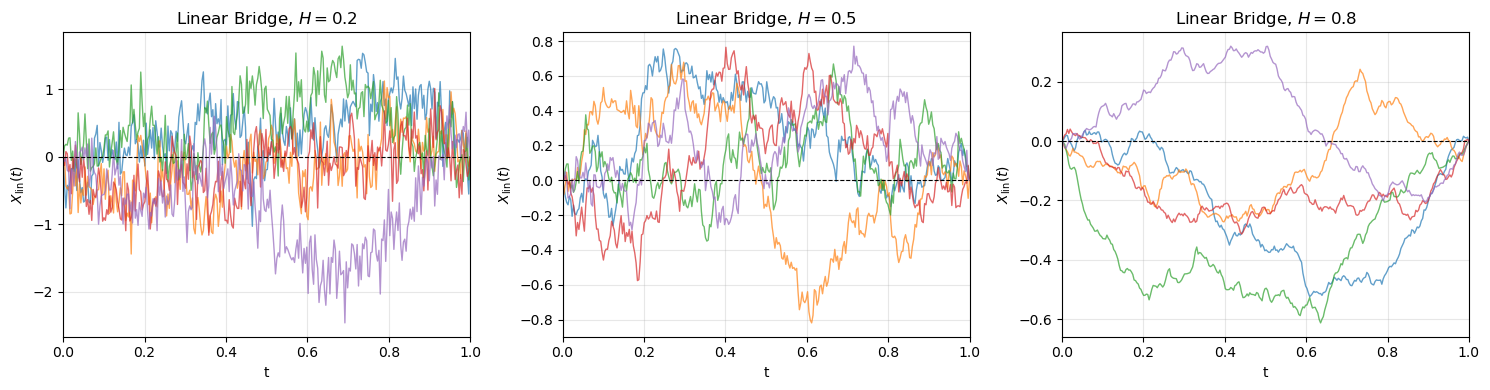

In [12]:
# Cell 3: Plot Sample Paths for Different H Values

n = 300
T = 1.0
t = np.linspace(0, T, n)
H_values = [0.2, 0.5, 0.8]
n_paths = 5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, H in enumerate(H_values):
    ax = axes[idx]
    
    for _ in range(n_paths):
        X_lin = linear_bridge(t, H)
        ax.plot(t, X_lin, alpha=0.7, linewidth=1.0)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(rf'Linear Bridge, $H = {H}$')
    ax.set_xlabel('t')
    ax.set_ylabel(r'$X_{\mathrm{lin}}(t)$')
    ax.set_xlim(0, T)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fbb_sample_paths.png'), dpi=150, bbox_inches='tight')
plt.show()


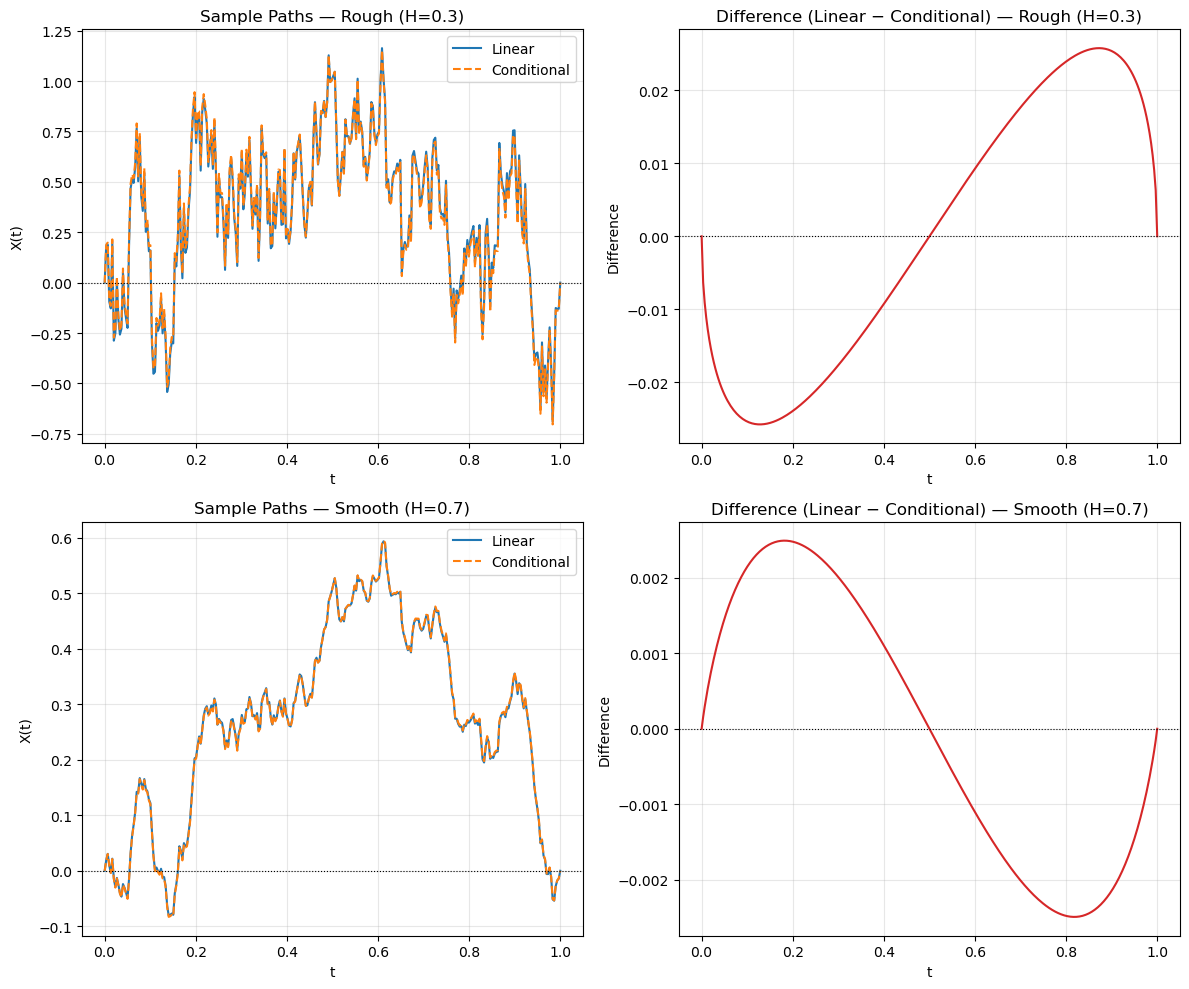

In [13]:
# Cell 4: Compare Linear vs Conditional Bridge

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
H_pairs = [(0.3, 'Rough (H=0.3)'), (0.7, 'Smooth (H=0.7)')]

for row, (H, title_suffix) in enumerate(H_pairs):
    np.random.seed(123)
    X_base = generate_fbm(t, H)
    T = t[-1]
    
    X_lin = X_base - (t / T) * X_base[-1]
    
    C_tT = 0.5 * (t**(2*H) + T**(2*H) - np.abs(T - t)**(2*H))
    C_TT = T**(2*H)
    X_cond = X_base - (C_tT / C_TT) * X_base[-1]
    
    ax = axes[row, 0]
    ax.plot(t, X_lin, label='Linear', color='tab:blue', linewidth=1.5)
    ax.plot(t, X_cond, label='Conditional', color='tab:orange', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
    ax.set_title(rf'Sample Paths — {title_suffix}')
    ax.set_xlabel('t')
    ax.set_ylabel('X(t)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[row, 1]
    diff = X_lin - X_cond
    ax.plot(t, diff, color='tab:red', linewidth=1.5)
    ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
    ax.set_title(rf'Difference (Linear − Conditional) — {title_suffix}')
    ax.set_xlabel('t')
    ax.set_ylabel('Difference')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fbb_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Theoretical Covariance Structure

The covariance matrices reveal the structural difference between the two bridges. For $H \neq 0.5$, the conditional bridge has a different "pinching" behavior near the endpoints.


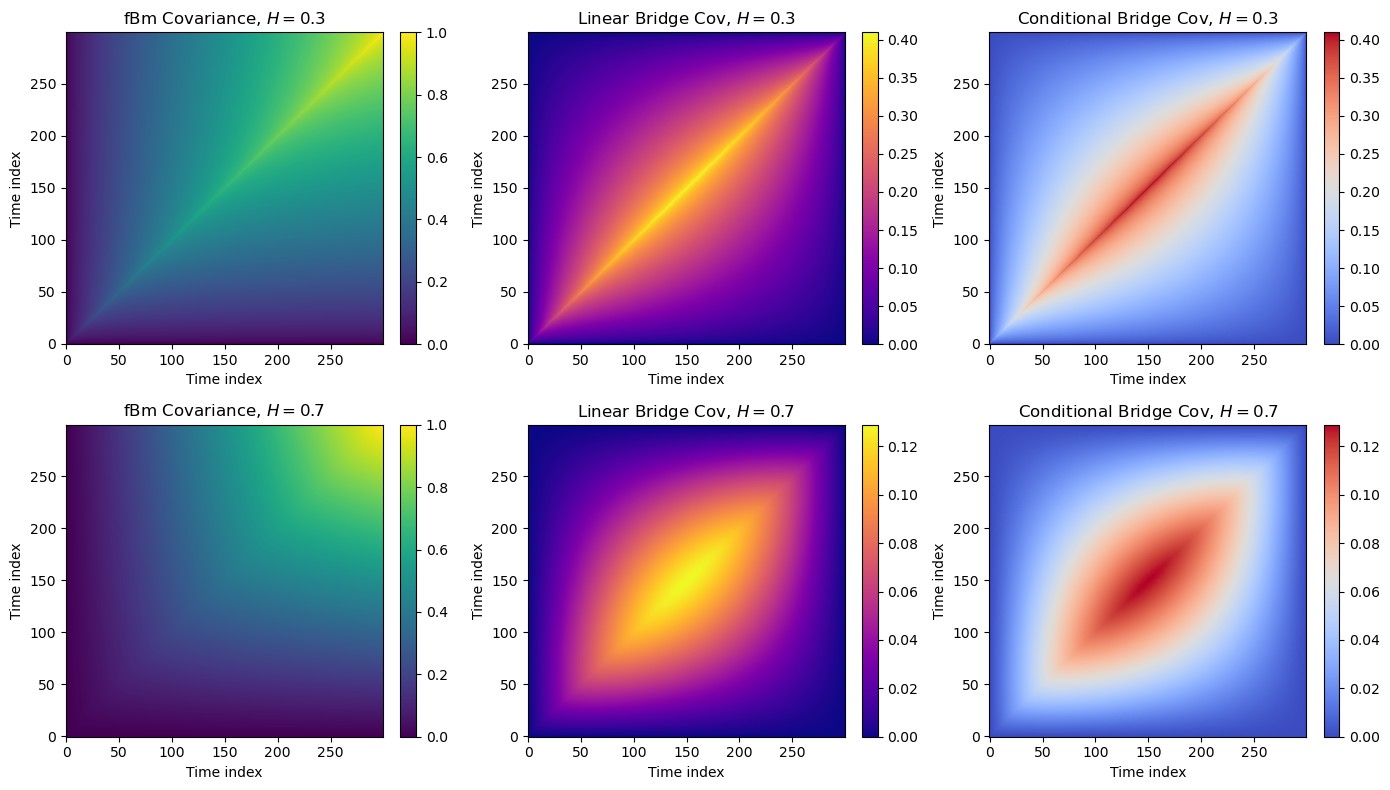

In [14]:
# Cell 5: Covariance Matrix Heatmaps

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, H in enumerate([0.3, 0.7]):
    C = fbm_covariance(t, H)
    T = t[-1]
    C_tT = 0.5 * (t**(2*H) + T**(2*H) - np.abs(T - t)**(2*H))
    C_TT = T**(2*H)
    
    C_cond = C - np.outer(C_tT, C_tT) / C_TT
    C_lin = C - np.outer(t/T, C_tT) - np.outer(C_tT, t/T) + np.outer(t/T, t/T) * C_TT
    
    im0 = axes[row, 0].imshow(C, aspect='auto', origin='lower', cmap='viridis')
    axes[row, 0].set_title(rf'fBm Covariance, $H={H}$')
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)
    
    im1 = axes[row, 1].imshow(C_lin, aspect='auto', origin='lower', cmap='plasma')
    axes[row, 1].set_title(rf'Linear Bridge Cov, $H={H}$')
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)
    
    im2 = axes[row, 2].imshow(C_cond, aspect='auto', origin='lower', cmap='coolwarm')
    axes[row, 2].set_title(rf'Conditional Bridge Cov, $H={H}$')
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

for ax in axes.flat:
    ax.set_xlabel('Time index')
    ax.set_ylabel('Time index')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fbb_covariance.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Variance Profile

The variance $\mathrm{Var}(X(t))$ as a function of time shows how the bridge "pinches" toward zero at the boundaries. For the conditional bridge, this is not symmetric when $H \neq 0.5$.

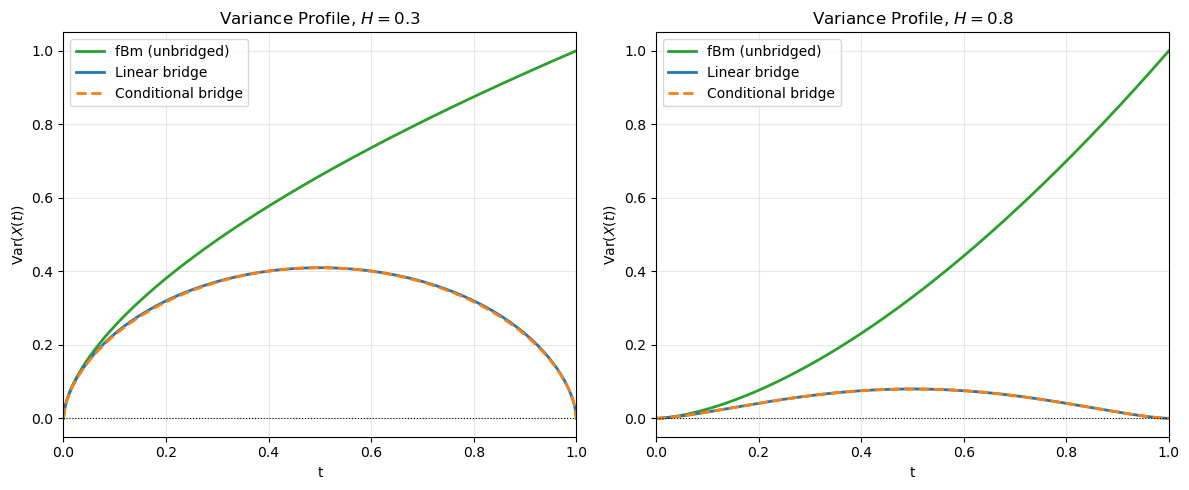

In [15]:
# Cell 6: Theoretical Variance Profiles

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, H in enumerate([0.3, 0.8]):
    ax = axes[idx]
    C = fbm_covariance(t, H)
    T = t[-1]
    C_tT = 0.5 * (t**(2*H) + T**(2*H) - np.abs(T - t)**(2*H))
    C_TT = T**(2*H)
    
    var_fbm = np.diag(C)
    var_lin = np.diag(C - np.outer(t/T, C_tT) - np.outer(C_tT, t/T) + np.outer(t/T, t/T) * C_TT)
    var_cond = np.diag(C - np.outer(C_tT, C_tT) / C_TT)
    
    ax.plot(t, var_fbm, label='fBm (unbridged)', color='tab:green', linewidth=2)
    ax.plot(t, var_lin, label='Linear bridge', color='tab:blue', linewidth=2)
    ax.plot(t, var_cond, label='Conditional bridge', color='tab:orange', linewidth=2, linestyle='--')
    ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
    ax.set_title(rf'Variance Profile, $H = {H}$')
    ax.set_xlabel('t')
    ax.set_ylabel(r'$\mathrm{Var}(X(t))$')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, T)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fbb_variance.png'), dpi=150, bbox_inches='tight')
plt.show()


## 9. Monte Carlo Validation

We can validate our simulations by comparing the empirical covariance from many sample paths against the theoretical formulas.


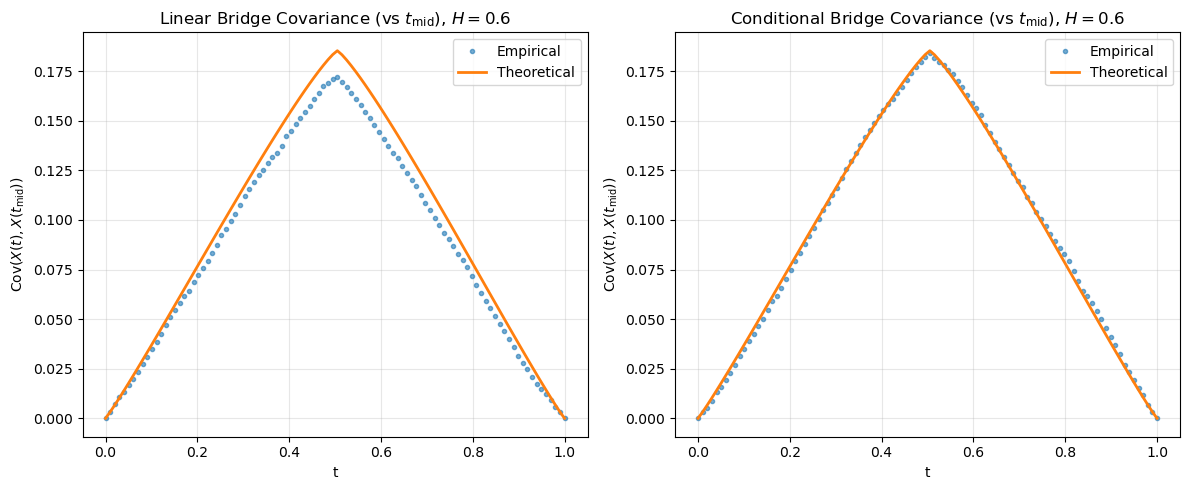

Max covariance error (Linear):     0.015402
Max covariance error (Conditional): 0.006980


In [16]:
# Cell 7: Monte Carlo Validation

n_sims = 2000
H = 0.6
T = 1.0
t = np.linspace(0, T, 100)

paths_lin = np.zeros((n_sims, len(t)))
paths_cond = np.zeros((n_sims, len(t)))

for i in range(n_sims):
    paths_lin[i, :] = linear_bridge(t, H)
    paths_cond[i, :] = conditional_bridge(t, H)

mid_idx = len(t) // 2
emp_cov_lin = np.cov(paths_lin.T)
emp_cov_cond = np.cov(paths_cond.T)

C = fbm_covariance(t, H)
C_tT = 0.5 * (t**(2*H) + T**(2*H) - np.abs(T - t)**(2*H))
C_TT = T**(2*H)
theo_cov_lin = C - np.outer(t/T, C_tT) - np.outer(C_tT, t/T) + np.outer(t/T, t/T) * C_TT
theo_cov_cond = C - np.outer(C_tT, C_tT) / C_TT

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(t, emp_cov_lin[:, mid_idx], 'o', markersize=3, alpha=0.6, label='Empirical')
ax.plot(t, theo_cov_lin[:, mid_idx], '-', linewidth=2, label='Theoretical')
ax.set_title(rf'Linear Bridge Covariance (vs $t_{{\mathrm{{mid}}}}$), $H={H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$\mathrm{Cov}(X(t), X(t_{\mathrm{mid}}))$')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t, emp_cov_cond[:, mid_idx], 'o', markersize=3, alpha=0.6, label='Empirical')
ax.plot(t, theo_cov_cond[:, mid_idx], '-', linewidth=2, label='Theoretical')
ax.set_title(rf'Conditional Bridge Covariance (vs $t_{{\mathrm{{mid}}}}$), $H={H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$\mathrm{Cov}(X(t), X(t_{\mathrm{mid}}))$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fbb_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

err_lin = np.max(np.abs(emp_cov_lin - theo_cov_lin))
err_cond = np.max(np.abs(emp_cov_cond - theo_cov_cond))
print(f"Max covariance error (Linear):     {err_lin:.6f}")
print(f"Max covariance error (Conditional): {err_cond:.6f}")


## 10. Summary

| Property | Linear Bridge | Conditional Bridge |
|----------|--------------|-------------------|
| **Formula** | $X(t) - \frac{t}{T}X(T)$ | $X(t) - \frac{\mathrm{Cov}(X(t),X(T))}{\mathrm{Var}(X(T))}X(T)$ |
| **Endpoints** | Pinned to 0 | Pinned to 0 |
| **Correct conditional law?** | Only for $H=0.5$ | Yes, for all $H$ |
| **Variance symmetry** | Symmetric about $t=T/2$ | Asymmetric for $H \neq 0.5$ |
| **Use case** | Simple, fast | Statistically rigorous |

### Key Takeaways
1. For **$H=0.5$** (standard Brownian motion), both bridges are identical because fBm is Markovian.
2. For **$H > 0.5$**, the conditional bridge is "pulled" more strongly toward zero near the endpoint due to long-range dependence.
3. For **$H < 0.5$**, the anti-persistent nature creates a different pinching pattern.
4. The **Cholesky method** is conceptually transparent but $O(N^3)$ — for large $N$ (thousands of points), use circulant embedding methods instead.